<a href="https://colab.research.google.com/github/Yu-hsiu/QuaCCAToo/blob/main/QuaCCAToo_%E6%95%99%E5%AD%B8_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QuaCCAToo 教學:NV center 數位雙生上手

本檔對應教學文件 `QuaCCAToo_教學_HackMD.md`,節次編號一致。

- 套件:https://github.com/Yu-hsiu/QuaCCAToo (本專案 fork,含五項修復)
- 論文:*QuaCCAToo: a Quantum Color Center Analysis Toolbox*, arXiv:2507.18759v2

**執行方式**:上方選單「執行階段 → 全部執行」,約 12 分鐘(含安裝)。
每一格都可獨立重跑,改參數後重跑該格即可。

**閱讀方式**:每一節都是「先講物理 → 再對照程式碼」。§1 是完全從零的 NV 背景,
已經熟 NV 的人直接跳到 §2。

---
# §1. 從零開始:NV center 是什麼,為什麼要模擬它

熟 NV 物理的人可以直接跳到 §2。

## 1.1 一顆鑽石裡的人造原子

鑽石是碳原子的規則晶格。把其中一個碳換成**氮**(Nitrogen),旁邊剛好又缺一個碳留下**空位**
(Vacancy),這組缺陷就叫 **NV center**。

這個缺陷會抓住一顆額外的電子變成 NV$^-$。氮原子多出來的價電子與一顆晶格電子配對,
可以形成**自旋三重態**($S=1$)或單重態($S=0$)。室溫下用來當量子位元的是三重態基態,
它有三個狀態,用自旋在 NV 軸方向的投影量子數標記:

$$m_S = +1, \quad m_S = 0, \quad m_S = -1$$

關鍵在於:**這三個狀態的能量不一樣,而且可以被操控、被讀出。** 一個能被操控與讀出的
量子系統,就是一個量子位元。

NV center 之所以受重視,是因為它在**室溫、常壓**下就能運作 —— 不用稀釋冷凍機。
用途包括奈米尺度磁場感測、量子網路節點、生物體內測溫。

## 1.2 能階從哪裡來:三個物理效應疊起來

### (a) 零場分裂 $D$ —— 不用磁場就有的分裂

兩顆電子的自旋之間有**偶極-偶極交互作用**。這個交互作用讓 $m_S = 0$ 與 $m_S = \pm 1$
差了 $D = 2.87$ GHz,**即使外加磁場為零**。這是 NV 的招牌數字。

($D$ 會隨溫度微幅變化,因為晶格常數會熱脹冷縮,電子間距一變偶極作用就變。
所以量 $D$ 就能量溫度 —— 這是 NV 溫度計的原理,也是 §5 那個 `temp` 參數的用途。)

### (b) Zeeman 效應 —— 磁場把 $\pm 1$ 拆開

加上外加磁場 $\mathbf{B}_0$,電子自旋的磁矩與磁場作用,$m_S = +1$ 與 $m_S = -1$ 被拆開,
間距正比於磁場($\gamma_e = 28.025$ GHz/T)。

**這就是 NV 當磁力計的原理**:量出兩條微波共振線的間距,就反推出磁場。

有一個特殊磁場值要記:$B_0 = D/\gamma_e = 102.4$ mT。在這裡 $m_S = -1$ 剛好**降到與
$m_S = 0$ 一樣低**,再高就掉到下面去了。這個交叉點叫 **GSLAC**(基態能階反交叉)。
§2.5 會說明它為什麼會在程式裡咬人。

### (c) 超精細耦合 —— 附近核自旋的影響

NV 附近有核自旋時,核自旋的小磁矩會在電子處產生額外磁場,讓電子的躍遷頻率
**隨核自旋的狀態而不同**。這叫**超精細耦合**(hyperfine coupling)。兩種來源:

- **氮原子自己的核自旋**:$^{14}$N($I=1$,自然豐度 99.6%)或 $^{15}$N($I=1/2$)。跑不掉。
- **附近的 $^{13}$C**:碳有 1.1% 是 $^{13}$C,有核自旋。位置隨機,耦合強度從上百 MHz(很近)
  到幾十 kHz(較遠)都有。

超精細耦合是本教學的主角:**它既是雜訊,也是資源。** 強耦合的 $^{13}$C 可以當第二個
量子位元用(§4);弱耦合的可以被偵測、被當成感測目標(§6)。

## 1.3 怎麼初始化、怎麼讀出:綠光進、紅光出

這是 NV 最漂亮的部分,也是它能室溫工作的原因。

**初始化**:打一道綠光(510–540 nm)。電子被激發到激發態,回來時有兩條路 ——
直接放紅光掉回原本的 $m_S$,或者繞道經過一個中間單重態(intersystem crossing)。
關鍵是 **$m_S = \pm 1$ 比較容易繞道,而繞道回來大多落在 $m_S = 0$**。
照個幾微秒,population 就被泵到 $m_S = 0$。不需要低溫。

**讀出**:同一個機制反過來用。$m_S = \pm 1$ 因為會繞道(那條路不放紅光),**看起來比較暗**。
所以**紅色螢光強度 $\propto$ $m_S = 0$ 的佔比**。

這就是整份 notebook 裡那個 observable 的意義:

$$\mathcal{F}_S = \langle\, |m_S = 0\rangle\langle m_S = 0| \,\rangle$$

所有圖的 y 軸「Observable」都是這個 —— **電子自旋停在 $m_S=0$ 的機率**,1 代表最亮。

## 1.4 怎麼操控:微波與射頻

$m_S = 0 \leftrightarrow \pm 1$ 的能量差在 **微波**(GHz)頻段,所以用微波脈衝操控電子自旋。
核自旋的躍遷小得多,在 **射頻**(MHz)頻段,所以用 RF 脈衝操控核自旋。

打一個共振的微波脈衝,電子就在兩個能階之間來回翻轉,這叫 **Rabi 振盪**。
翻轉的快慢叫 **Rabi 頻率 $\omega_1$**,正比於微波強度。

- 剛好翻半圈($|0\rangle \to |1\rangle$)= **$\pi$ 脈衝**,長度 $t_\pi = 1/(2\omega_1)$
- 翻四分之一圈(轉到疊加態)= **$\pi/2$ 脈衝**

整份 notebook 的脈衝序列就是這兩種積木排列組合出來的。

## 1.5 「數位雙生」是什麼意思,為什麼需要這個套件

Digital twin = 用電腦建一個跟真實裝置對應的模型:**餵進實驗參數,吐出實驗會量到的訊號。**

為什麼需要?因為 NV 實驗要調的參數很多(磁場大小、方向、脈衝長度、脈衝數、掃描範圍),
真的到實驗室一個一個試很貴。先在電腦上跑,知道該掃哪裡、會看到什麼形狀,再進實驗室。

**QuaCCAToo 特別的地方在於它不做近似。** 傳統做法會進「旋轉座標系」並套用 RWA
(旋轉波近似),把微波的高頻振盪消掉,計算快很多。代價是有些效應會被抹掉。
QuaCCAToo 老實地在實驗室座標系解方程,微波的餘弦函數原封不動留在 Hamiltonian 裡。

慢,但換到三樣東西:**有限脈衝長度造成的假訊號**(§7 會親眼看到)、
**hyperfine enhancement**、以及**量子傳送協定裡的相位累積**。這些都是 RWA 看不到的。

## 1.6 三個 Hamiltonian:整個套件的骨架

論文把物理拆成三塊,套件的類別就照這個切。**看懂這張表,就看懂整個套件。**

| 符號 | 是什麼 | 在程式裡 |
|---|---|---|
| $\hat H_0$ | 系統本身:零場分裂 + Zeeman + 超精細 + 四極矩。不隨時間變。 | `NV(...)` 建構時自動算好 |
| $\hat H_1(t)$ | 你打進去的控制場:微波、射頻脈衝。隨時間振盪。 | `h1` 算符 + `pulse_params` |
| $\hat H_2(t)$ | 被感測的對象:額外的核自旋,或外部振盪磁場。 | `add_spin(H2)` 或 `H2=[算符, f(t)]` |

一次模擬永遠是同一個流程:

```
建 NV 系統 → (可選)掛上被感測的自旋/場 → 選脈衝序列、給參數 → .run() → Analysis 出圖
```

| 脈衝序列類別 | 在做什麼 | 本教學章節 |
|---|---|---|
| `Rabi` | 掃脈衝長度,看自旋翻轉 | §4 |
| `Hahn` | 一個 $\pi$ 脈衝的自旋回聲 | §5 |
| `CPMG` | 重複 $M$ 個 $\pi$ 脈衝,窄帶濾波 | §6 |
| `XY8` | $\pi$ 脈衝軸在 x/y 交替,抗脈衝誤差 | §7 |
| `PulsedSim` | 自己排任意序列 | §8(僅說明) |

---
## §3. 安裝(對應文件 §3「環境」)

這是**第一格程式碼**,後面每一格都要用到它。只需要跑一次,約 1–2 分鐘。
(編號跟著文件走,所以排在 §1、§2 之後 —— 但它是最先執行的。)

In [1]:
!pip install -q git+https://github.com/Yu-hsiu/QuaCCAToo.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import jmat, tensor, qeye, basis

import quaccatoo
from quaccatoo import NV, Rabi, Hahn, CPMG, XY8, Analysis, square_pulse

print("QuaCCAToo", quaccatoo.__version__)

QuaCCAToo 1.3.0


---
## §2. 五個程式慣例

**這個套件的程式約定**。先花兩分鐘看過,後面的程式碼才讀得懂。
這一節很快,沒有模擬。

1. **單位**:頻率 MHz、時間 µs、$h=1$。零場分裂寫 `2.87e3`,10 ns 脈衝寫 `0.01`。
2. **$2\pi$ 已經幫你乘好**,而且是乘在時間軸上。你自訂的時間相依函數收到的 `t`
   已經是 $2\pi$ 縮放過的 —— 寫 `np.sin(5.5*t)` 就是 5.5 MHz,不要再乘 $2\pi$。
3. **`energy_levels[0]` 恆為 0**。算 manifold 平均時那個 0 要算進去。
4. **基底順序跟直覺相反**:`basis(3,0)` 是 $m_S=+1$、`basis(3,1)` 是 $m_S=0$、
   `basis(3,2)` 是 $m_S=-1$(因為 QuTiP `jmat(1,'z')` 對角線是 $[+1,0,-1]$)。
5. **能階順序 $\neq$ 基底順序**,而且過了 GSLAC(102.4 mT)會翻轉。
   不要自己用固定索引切 `energy_levels`,用 `MW_freqs` / `RF_freqs`。

In [3]:
# 慣例 3、4、5 的實地示範

demo = NV(B0=25, units_B0='mT', N=14)          # 14N,GSLAC 以下
print("能階 (MHz):", np.round(demo.energy_levels, 3))
print("energy_levels[0] =", demo.energy_levels[0], " <- 恆為 0")

# 慣例 4:jmat(1,'z') 的對角線
print("\njmat(1,'z') 對角線:", np.real(np.diag(jmat(1, 'z').full())))
print("  -> basis(3,0)=mS=+1, basis(3,1)=mS=0, basis(3,2)=mS=-1")

# 慣例 3:mS=0 manifold 是 energy_levels[0:3],平均要除以 3
print("\nmS=0 三個子能階的平均:")
print("  正確 np.sum(lv[1:3])/3 =", np.sum(demo.energy_levels[1:3]) / 3)
print("  錯誤 np.mean(lv[1:3])  =", np.mean(demo.energy_levels[1:3]), " <- 少算了那個 0")

# 慣例 5:GSLAC 兩側的能階順序
for B0 in (25, 200):
    nv = NV(B0=B0, units_B0='mT', N=14)
    print(f"\nB0={B0:>3} mT  MW_freqs = {np.round(nv.MW_freqs, 2)}"
          f"   (|0>-|-1>, |0>-|+1>)")

能階 (MHz): [0.000000e+00 1.530000e-01 5.084000e+00 2.167392e+03 2.171522e+03
 2.174469e+03 3.568486e+03 3.572922e+03 3.575715e+03]
energy_levels[0] = 0.0  <- 恆為 0

jmat(1,'z') 對角線: [ 1.  0. -1.]
  -> basis(3,0)=mS=+1, basis(3,1)=mS=0, basis(3,2)=mS=-1

mS=0 三個子能階的平均:
  正確 np.sum(lv[1:3])/3 = 1.7453638313698132
  錯誤 np.mean(lv[1:3])  = 2.61804574705472  <- 少算了那個 0

B0= 25 mT  MW_freqs = [2169.38 3570.63]   (|0>-|-1>, |0>-|+1>)

B0=200 mT  MW_freqs = [2734.99 8474.99]   (|0>-|-1>, |0>-|+1>)


> 上面 $B_0 = 200$ mT 的那組數字,在**修復前**的版本第二個會是 `11209.98`
> —— 那是禁戒的 $\Delta m_S = 2$ 躍遷,不是 $|0\rangle \leftrightarrow |{+}1\rangle$。
> 詳見 §9。

---
## §4. 條件 Rabi:兩量子位元閘(論文 FIG. 3)

### 這一節在做什麼物理

我們要做一個 **CNOT 閘** —— 量子計算最基本的雙位元閘之一:「**當**控制位元是 1,
**才**翻轉目標位元」。

這裡的兩個位元是:

- **控制位元** = 一顆強耦合 $^{13}$C 核自旋($m_I = \pm 1/2$)
- **目標位元** = NV 的電子自旋($m_S = 0 \leftrightarrow -1$)

**為什麼能做到「條件」?** 回顧 §1.2(c):超精細耦合讓電子的躍遷頻率隨核自旋狀態而不同。
這顆 $^{13}$C 的耦合是 $a_{zz} = 130$ MHz,非常強,所以兩個核自旋態對應的電子躍遷頻率
差了整整 130 MHz。

而這裡用的 Rabi 頻率是 $\omega_1 = 20$ MHz,$\pi$ 脈衝長 25 ns,頻寬大約也就是幾十 MHz
的量級 —— **遠小於 130 MHz 的間隔**。所以脈衝**打得中其中一個躍遷,打不中另一個**。
電子翻不翻,就取決於 $^{13}$C 在哪個狀態 —— CNOT 成立。

**為什麼要 $B_0 = 200$ mT 這麼大的磁場?** 為了讓四條能階($2 \times 2$ 組合)彼此分得夠開,
避免脈衝誤觸。注意 200 mT 已經在 GSLAC(102.4 mT)之上,所以 $m_S = -1$ 比 $m_S = 0$ 還低。

**這對應什麼實驗?** Jelezko *et al.* (2004),NV 領域最早的雙位元閘示範之一。

### 4.1–4.2 建系統、掛上 $^{13}$C

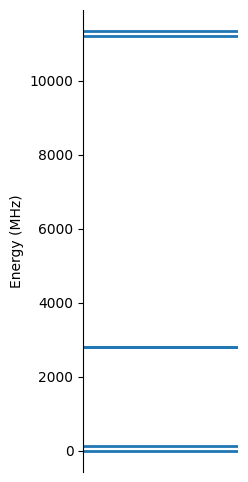

In [4]:
sys = NV(B0=200, units_B0='mT', N=0)      # N=0:忽略氮核自旋,維度 18 -> 6,快很多

GAMMA_C = 10.7084e-3      # 13C 旋磁比 MHz/mT
azz     = 130             # 超精細 MHz

# H2 = azz * Sz Iz  -  gamma_c B0 Iz      (論文 Eq. 8)
#   jmat(1,'z')   = Sz  (spin-1,電子)
#   jmat(1/2,'z') = Iz  (spin-1/2,13C)
#   核自旋 Zeeman 是「負」號,跟 NV.nuclear_zeeman 的慣例一致
H2 = (azz * tensor(jmat(1, 'z'), jmat(1/2, 'z'))
      - GAMMA_C * sys.B0 * tensor(qeye(3), jmat(1/2, 'z')))

sys.add_spin(H2)                                  # 自動把 MW_h1/RF_h1 擴張到新維度
sys.rho0 = tensor(basis(3, 1), basis(2, 0))       # |mS=0> ⊗ |mI=+1/2>

sys.plot_energy()

能階圖裡:$m_S = 0$ 的兩條只被 $^{13}$C 的 Zeeman 分開,$m_S = -1$ 的兩條還多了超精細貢獻。
兩者差很多,所以窄頻脈衝可以分開驅動 —— 這是條件閘成立的前提。

### 4.3–4.4 控制場與電子 Rabi

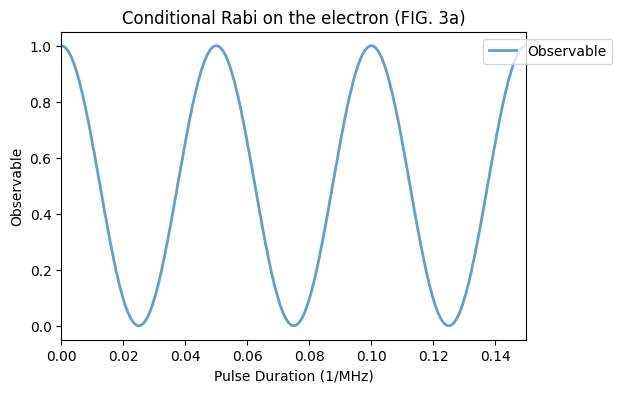

In [5]:
w1_S = 20     # 電子 Rabi 頻率 MHz
w1_I = 0.8    # 核自旋 Rabi 頻率 MHz

# 那兩個 sqrt(2) 與 2 是自旋算符對 Pauli 矩陣的歸一化因子(論文 Eq. 7 下方)
h1 = (w1_S * tensor(jmat(1, 'x') * 2**.5, qeye(2))
      + w1_I * tensor(qeye(3), jmat(1/2, 'x') * 2))

w0_mw = sys.energy_levels[2]     # 電子躍遷
w0_rf = sys.energy_levels[1]     # 核自旋躍遷

rabi_S = Rabi(
    system         = sys,
    pulse_duration = np.linspace(0, 0.15, 1000),   # 掃描變數:脈衝長度 (us)
    h1             = h1,
    pulse_params   = {'f_pulse': w0_mw},
    pulse_shape    = square_pulse,
)
rabi_S.run()
Analysis(rabi_S).plot_results(title='Conditional Rabi on the electron (FIG. 3a)')

### 怎麼讀這張圖

x 軸是**微波脈衝開多久**,y 軸是**電子停在 $m_S=0$ 的機率**(也就是螢光亮度)。

從 1 開始(初始化到 $m_S=0$,最亮),隨脈衝變長掉到 0(整群翻到 $m_S=-1$,最暗),
再回到 1 —— 這就是 **Rabi 振盪**。振盪一個完整週期 = 轉 $360°$。

- 第一次掉到谷底的位置就是 **$\pi$ 脈衝長度**($t_\pi = 1/(2\omega_1) = 25$ ns)
- 對比度接近 1,表示翻轉很乾淨

**關鍵在於這是「條件」的**:振盪只發生在 $^{13}$C 處於 $m_I = +1/2$ 的那一半系統上。
另一半($m_I = -1/2$)的躍遷頻率差了 130 MHz,完全沒被這個脈衝碰到。

### 4.5 換個角色:改驅動核自旋,並加入退相干

現在反過來 —— 用 RF 脈衝驅動 $^{13}$C 核自旋,而且**條件是電子在 $m_S=-1$**
(因為核自旋的躍遷頻率也隨電子狀態而不同,同一個超精細耦合的另一面)。
這在實驗上叫 **ENDOR**(電子-核雙共振)。

同時加入**退相干**:真實的核自旋會跟環境作用,相位逐漸隨機化,振盪會**衰減**。
用 Lindblad 主方程的 collapse operator $\hat C = \hat I_z^c$、速率 $\Gamma_2 = 0.5$ MHz 描述。

兩件事會跟上一格明顯不同,看圖時注意:

1. **振盪週期長很多** —— 核自旋的旋磁比比電子小三個數量級($\gamma_n \ll \gamma_e$),
   同樣強度的驅動場給出小得多的 Rabi 頻率。x 軸範圍從 0.15 µs 變成 2.5 µs。
2. **振幅逐漸衰減** —— 這就是退相干。

> **效能提醒**:設了 `c_ops` 之後,系統從純態(ket,$d$ 個數字)變成密度矩陣($d^2$ 個數字),
> 要解的 ODE 數量平方成長,所以這格比上一格慢一個數量級。
> **不需要模擬弛豫就別設 `c_ops`。**

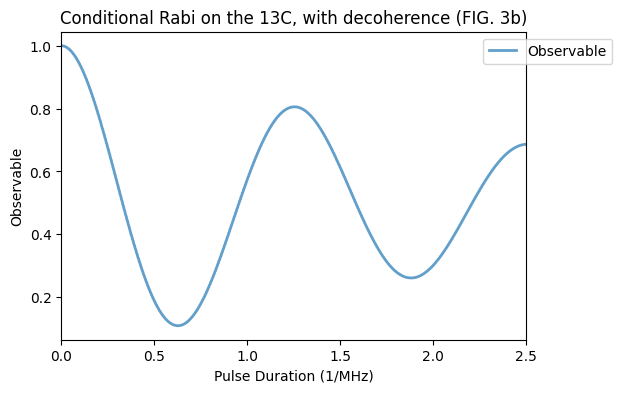

In [6]:
sys.rho0       = tensor(basis(3, 2), basis(2, 0))                    # |mS=-1> ⊗ |mI=+1/2>
sys.observable = tensor(qeye(3), basis(2, 0) * basis(2, 0).dag())    # 改測核自旋
sys.c_ops      = 0.5 * tensor(qeye(3), jmat(1/2, 'z'))               # 退相干

rabi_I = Rabi(
    system         = sys,
    pulse_duration = np.linspace(0, 2.5, 1000),
    h1             = h1,
    pulse_params   = {'f_pulse': w0_rf},
)
rabi_I.run()
Analysis(rabi_I).plot_results(title='Conditional Rabi on the 13C, with decoherence (FIG. 3b)')

振盪被阻尼掉了,而且週期長很多($\gamma_n \ll \gamma_e$,同樣的 $B_1$ 給出小得多的 Rabi 頻率)。

---
## §5. Hahn echo 與 ESEEM(論文 FIG. 4a)

### 這一節在做什麼物理

**要解決的問題**:把電子自旋轉到疊加態之後,它會因為周圍環境的雜散磁場而**失去相位**。
每顆 NV(或每次量測)感受到的局部磁場都略有不同,轉的速度就略有不同,疊加起來訊號很快
就糊掉了。這個衰減時間叫 $T_2^*$,通常只有微秒等級 —— 太短,什麼都做不了。

**Hahn echo 的技巧**(1950 年 NMR 就發明了,自旋回聲):

```
π/2 ─── 等 τ ─── π ─── 等 τ ─── π/2 ── 讀出
```

前半段跑得快的自旋累積了比較多相位,跑得慢的比較少。中間那個 $\pi$ 脈衝**把所有相位翻轉
180°** —— 原本領先的變落後。接下來後半段再等一樣長的 $\tau$,快的追回來、慢的被追上,
**在 $2\tau$ 時刻所有人剛好重新對齊**。訊號「回聲」般地復活。

用跑步比喻:一群人跑步速度不同,跑 $\tau$ 秒後吹哨要所有人**掉頭跑回來**,
再過 $\tau$ 秒,不管快慢,大家同時回到起點。

**但這招只對「不變的東西」有效。** 如果某個雜訊源在這 $2\tau$ 期間**自己也在變**,
它造成的相位就抵銷不掉 —— 會留下痕跡。

**這正是我們要的。** 附近的 $^{13}$C 核自旋一直在**進動**(繞著磁場旋轉)。它抵銷不掉,
於是在 echo 訊號上留下**週期性的調變**。掃描 $\tau$ 就會看到訊號上下起伏,
這叫 **ESEEM**(電子自旋回聲包絡調變)。

**調變頻率 = $^{13}$C 的進動頻率。量到它,就等於偵測到那顆 $^{13}$C 的存在與位置。**

而且會看到**兩個**頻率疊在一起,因為 $^{13}$C 感受到的總磁場在電子處於 $m_S=0$ 和
$m_S=+1$ 時不一樣(超精細耦合只在 $m_S \neq 0$ 時作用):

- **慢的**:$m_S = 0$,超精細不作用,就是純 Zeeman 進動($\gamma_c B_0$)
- **快的**:$m_S = +1$,超精細場疊加上去

### 三個新參數,以及它們的物理意義

- **`theta = -45°`** —— $\mathbf{B}_0$ 與 NV 軸的夾角。**這不是隨便設的**:磁場對齊時
  ($\theta = 0$)電子的本徵態很乾淨,ESEEM 幾乎看不到;傾斜會造成**電子態混合**,
  才讓核自旋的躍遷「被允許」。§5 最後會叫你把它改成 0 親眼驗證。
- **`N = 14`** —— 這次氮核自旋不能忽略。它自己的超精細耦合會微調電子的躍遷頻率,
  改變 echo 包絡的形狀。$^{14}$N 有 $I=1$,三個核自旋態,所以維度變成 $3 \times 3 \times 2 = 18$。
- **`temp = 300 K`** —— 給了溫度,初態就依 Boltzmann 分布算(而不是假設核自旋完全隨機),
  同時零場分裂 $D$ 會依 §1.2(a) 說的溫度多項式修正。適用 5.6–700 K,超出會發警告。

**對應實驗**:Childress *et al.* (2006),Science。

**這一節約 1.5 分鐘。**

In [7]:
sys1 = NV(B0=4.2, units_B0='mT',
          theta=-45, units_angles='deg',
          N=14, temp=300, units_temp='K')

# 論文 Sec. III B 的超精細張量 (MHz)
alpha = np.array([[ 5.0, -6.3, -2.9],
                  [-6.3,  4.2, -2.3],
                  [-2.9, -2.3,  8.2]])
ax = ['x', 'y', 'z']

H2 = sum(alpha[i, j] * tensor(jmat(1, ax[i]), qeye(3), jmat(1/2, ax[j]))
         for i in range(3) for j in range(3))
H2 = H2 - GAMMA_C * sys1.B0 * tensor(
    qeye(3), qeye(3),
    np.cos(sys1.theta) * jmat(1/2, 'z') + np.sin(sys1.theta) * jmat(1/2, 'x'))

sys1.add_spin(H2)

# mS=+1 六個子能階的平均 減 mS=0 六個的平均。
# 兩個分母都是 6 —— energy_levels[0] 是 0,也要算進去(慣例 3)
w0 = np.sum(sys1.energy_levels[12:]) / 6 - np.sum(sys1.energy_levels[1:6]) / 6
print("MW 頻率 =", round(w0, 4), "MHz")

MW 頻率 = 2956.9367 MHz


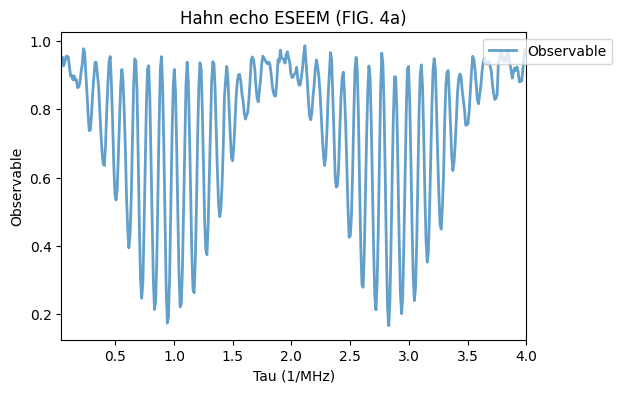

In [8]:
hahn = Hahn(
    free_duration     = np.linspace(0.04, 4, 400),   # tau,不是脈衝間距!
    pi_pulse_duration = 0.0316,                      # ~31.6 ns
    system            = sys1,
    h1                = 15 * sys1.MW_h1,             # MW_h1 是備好的 sqrt(2)*Sx
    pulse_params      = {'f_pulse': w0},
    projection_pulse  = True,                        # 尾端加 pi/2 轉回量子化軸
    time_steps        = 1000,                        # 每個脈衝內的離散點數
)
hahn.run()
Analysis(hahn).plot_results(title='Hahn echo ESEEM (FIG. 4a)')

### 怎麼讀這張圖

x 軸是 $\tau$(半個 echo 的等待時間),y 軸一樣是 $m_S=0$ 的機率。

看到的不是平滑衰減,而是**明顯的週期起伏** —— 這就是 ESEEM。仔細看會發現是
**兩個頻率疊在一起**:一個慢的大包絡,上面疊著快的細紋。

- **慢的** = $m_S=0$ 時 $^{13}$C 的進動頻率(純 Zeeman,$\gamma_c B_0$)
- **快的** = $m_S=+1$ 時的(超精細場疊上去)

**這張圖的物理意義**:每一個起伏都在告訴你「附近有一顆核自旋,它以這個頻率進動」。
在不同磁場大小與方向下重複量這些頻率,就能**反推出整個超精細張量** ——
也就是那顆 $^{13}$C 相對於 NV 的**位置與方向**。這是用一顆電子自旋當探針,
做出原子級解析度的結構定位。

### 動手驗證一件事

把上面那格的 `theta=-45` 改成 `theta=0`(磁場對齊 NV 軸)再重跑。

**預期**:調變會大幅減弱甚至消失。因為對齊時電子的本徵態是乾淨的 $|m_S\rangle$,
核自旋躍遷被禁戒;傾斜造成的態混合才是 ESEEM 的來源。

這是驗證你有沒有真的理解這節物理的最快方法 —— 改一個參數,預測會發生什麼,然後看對不對。

---
## §6. CPMG 偵測弱耦合 $^{13}$C(論文 FIG. 4b)

### 這一節在做什麼物理

**難度升級**:這次的 $^{13}$C 超精細耦合只有 **55 kHz** —— 比 §4 那顆(130 MHz)
**弱了三個數量級**。它離 NV 遠得多。用 §5 的 Hahn echo 根本看不到,訊號被雜訊淹沒。

**解法:把 $\pi$ 脈衝重複很多次。**

```
π/2 ─ τ/2 ─ π ─ τ ─ π ─ τ ─ π ─ … ─ τ/2 ─ π/2 ── 讀出
                    └──── 重複 M 次 ────┘
```

這叫 **CPMG**(Carr-Purcell-Meiboom-Gill)。

### 為什麼重複會有用:把它想成一個濾波器

Hahn echo(一個 $\pi$ 脈衝)可以想成一個很**寬**的帶通濾波器 —— 擋掉靜態雜訊,
但對各種頻率的動態雜訊都只有粗糙的區分能力。

**每多加一個 $\pi$ 脈衝,這個濾波器就更窄一點。** $M$ 個脈衝之後,它變成一個
**梳狀的窄帶濾波器**,只讓特定頻率通過:

$$f_0 = \frac{1}{2\tau} \quad \text{以及它的奇數倍} \quad 3f_0,\ 5f_0,\ \dots$$

**關鍵洞察**:$\tau$ 是你掃描的變數,所以**掃 $\tau$ 就等於掃這個濾波器的中心頻率**。
當 $1/(2\tau)$(的某個奇數倍)剛好對上 $^{13}$C 的進動頻率,電子就「聽見」它 ——
訊號出現共振。其他所有頻率的雜訊都被 $M$ 個脈衝過濾掉了。

這就是為什麼一個 55 kHz 的微弱耦合,能從一整片雜訊背景裡被撈出來。

### 「第 8 階共振」是什麼意思

$\tau \approx 16.8$ µs 對應 $f_0 = 1/(2\tau) \approx 30$ kHz,而 $^{13}$C 的進動頻率
大約是 0.89 MHz —— 對不上。但 $f_0$ 的**第 8 個諧波**($k=8$)剛好對上,所以在這裡共振。

共振條件是:

$$\tau_k = \frac{2k-1}{f_n(m_S{=}0) + f_n(m_S{=}{-}1)}$$

分母是 $^{13}$C 在兩個電子態下進動頻率的和。$k=8$ 時算出 $\tau_8 = 16.797$ µs
—— 這個數字**完全由物理參數決定,不用跑模擬**。下面會拿它跟模擬結果對答案。

### 為什麼這件事重要:不只是偵測,還能拿來做閘

共振發生時,電子自旋與那顆 $^{13}$C **糾纏**起來。改變脈衝數 $M$ 就改變糾纏的程度,
所以**只用打在電子上的微波脈衝,就能對核自旋做條件邏輯閘** —— 完全不用碰核自旋。

微波脈衝又快又準,這讓遠處的 $^{13}$C 變成可用的量子記憶體。這就是 FIG. 4(b) 裡
「共振強度隨 $M$ 振盪」的意義:那條振盪曲線就是閘操作的校準曲線。

**對應實驗**:Taminiau *et al.* (2012), PRL 109, 137602。

**這一節約 3 分鐘**(M=32,每個 $\tau$ 點要積 32 個脈衝)。

In [9]:
# tutorial 04 對 13C 用的旋磁比是 10.705e-3(§4 用的是 10.7084e-3)。
# 這裡沿用 tutorial 04 的值,才能跟套件自附的參考資料對得上。
GAMMA_C_T4 = 10.705e-3

sys2 = NV(B0=40.1, units_B0='mT', N=14)

axz  = 0.055 * np.sin(np.pi * 54 / 180)     # 超精細張量的 zx 分量
azz2 = 0.055 * np.cos(np.pi * 54 / 180)     # zz 分量

H2 = (axz * (tensor(jmat(1, 'x'), qeye(3), jmat(1/2, 'z'))
             + tensor(jmat(1, 'z'), qeye(3), jmat(1/2, 'x')))
      + azz2 * tensor(jmat(1, 'z'), qeye(3), jmat(1/2, 'z'))
      - GAMMA_C_T4 * sys2.B0 * tensor(qeye(3), qeye(3), jmat(1/2, 'z')))
sys2.add_spin(H2)

# 這次驅動 mS=0 <-> mS=-1。energy_levels 按能量排序,GSLAC 以下 mS=-1 排在中間 [6:12]
w0_cpmg = np.mean(sys2.energy_levels[6:12]) - np.sum(sys2.energy_levels[1:6]) / 6

# ---- 共振位置可以純解析預測,完全不用模擬 ----
# 13C 在兩個電子態下的進動頻率:
#   mS= 0:超精細不作用,就是純 Zeeman
#   mS=-1:超精細場與 Zeeman 場向量相加
f_n_0  = GAMMA_C_T4 * sys2.B0
f_n_m1 = np.hypot(GAMMA_C_T4 * sys2.B0 + azz2, axz)

k = 8                                          # 第 8 階共振
tau_k_predicted = (2*k - 1) / (f_n_0 + f_n_m1)

print(f"13C 進動  mS= 0 : {f_n_0:.4f} MHz")
print(f"13C 進動  mS=-1 : {f_n_m1:.4f} MHz")
print(f"預測第 {k} 階共振 : {tau_k_predicted:.4f} us")

13C 進動  mS= 0 : 0.4293 MHz
13C 進動  mS=-1 : 0.4637 MHz
預測第 8 階共振 : 16.7971 us


In [ ]:
tau = np.linspace(16.76, 16.83, 50)

cpmg = CPMG(
    free_duration     = tau,
    pi_pulse_duration = 0.00999483,       # tutorial 04 校準過的 pi 脈衝(論文正文寫 10 ns)
    system            = sys2,
    h1                = 50 * sys2.MW_h1,  # w1 = 1/(2*0.01) = 50 MHz
    pulse_shape       = square_pulse,
    pulse_params      = {'f_pulse': w0_cpmg},
    M                 = 32,               # pi 脈衝數。M=16 對比只有 0.15,M=32 才看得清楚
    time_steps        = 1000,
    # 論文寫 atol=rtol=1e-16,那是空轉:慢 7.5 倍,結果只差 1e-7
    options           = {'atol': 1e-12, 'rtol': 1e-10, 'nsteps': 1e8, 'order': 30},
)
cpmg.run()

results  = np.asarray(cpmg.results, dtype=float)
tau_peak = tau[np.argmax(results)]           # 這個 M 下共振是向上的峰

print(f"預測 {tau_k_predicted:.4f} us   模擬峰 {tau_peak:.4f} us"
      f"   相對偏差 {abs(tau_peak - tau_k_predicted)/tau_k_predicted:.2%}")
print(f"背景 {results[0]:.4f}   峰值 {results.max():.4f}")

Analysis(cpmg).plot_results(title='CPMG-32 on a weakly coupled 13C (FIG. 4b)')

**兩條獨立路徑對上了** —— 純解析預測 16.797 µs,模擬峰 16.791 µs,相對偏差 0.03%。
這才是「重現成功」的判準,光看圖形狀像不算數。
(剩下的 0.03% 來自解析式用了 secular 近似,模擬沒有。)

第三條路徑是套件自附的作者資料 `docs/tutorials/sim_data_tutorials/CPMG-*_13C`
(pip 安裝不會帶進來,要 clone repo)。本專案的重現逐點比對過那份資料:

| M | 背景 | 峰值 | 峰位置 |
|---|---|---|---|
| 16 | 0.1462 | 0.2162 | 16.7914 |
| 32 | 0.0502 | 0.6516 | 16.7914 |

$M=16$ 的對比本來就很低,所以上面示範用 $M=32$。把 `M` 換成 16 / 32 / 56 / 96
疊起來就是論文 FIG. 4(b):共振強度隨 $M$ 振盪 —— 這正是可以只靠電子 MW 脈衝
對 $^{13}$C 做條件閘的物理基礎。完整四條曲線 × 200 點在 Colab 雙核要跑 **4 小時 17 分**。

---
## §7. 半古典:XY8 感測外部振盪場(論文 FIG. 5)

### 這一節在做什麼物理

**換一種被感測的對象。** §4–§6 感測的都是**量子自旋**(要把它加進 Hilbert 空間,維度變大)。
這節改成感測一個**古典的振盪磁場**:

$$\mathbf{B}_2(t) = B_2 \sin(\omega_2 t)\,\mathbf{z}, \qquad \gamma_e B_2 = 0.3\ \text{MHz},\ \ \omega_2 = 5.5\ \text{MHz}$$

這叫**半古典**處理:不用擴張 Hilbert 空間,只要在 Hamiltonian 裡加一個隨時間振盪的項。
計算便宜很多。這也是 NV 磁力計的實際應用場景 —— 你要測的是外部訊號,不是某顆特定核自旋。

濾波器的圖像跟 §6 完全一樣:主共振出現在濾波器中心頻率對上訊號頻率的地方,

$$\tau_0 = \frac{1}{2\omega_2} = \frac{1}{2 \times 5.5} \approx 0.0909\ \mu\text{s}$$

### XY8 比 CPMG 好在哪

CPMG 的 $\pi$ 脈衝全部繞同一個軸(x)轉。真實的脈衝一定有誤差(長度差 1%、頻率有偏),
**同軸的誤差會一路累加** —— 32 個脈衝之後就歪掉了。

**XY8 讓 $\pi$ 脈衝的旋轉軸在 x 和 y 之間交替**,順序是 $x\,y\,x\,y\,y\,x\,y\,x$
(反對稱排列),然後這 8 個一組重複 $M$ 次。x 的誤差在下一個 x 被抵銷,y 同理。
**誤差自己抵銷,而不是累加。** 這讓長序列變得可行。

### 這節的重頭戲:看見 RWA 看不到的假訊號

跑完會看到主共振旁邊還有一些**較小的峰**,位置在 $\tau_0$ 的
$3/4$、$5/4$、$3/2$、$7/4$ 倍 —— 這些叫 **spurious harmonics**(假諧波)。

**它們從哪來?** 因為**脈衝有長度**。理想模型假設 $\pi$ 脈衝是瞬間完成的($\delta$ 脈衝),
但真實脈衝要花 25 ns,**在這段期間系統仍在自由演化**。這個「脈衝進行中的演化」讓濾波函數
多出了本來不該有的通帶。

**這就是不做 RWA 的價值。** 用旋轉座標近似的模型會直接把這些效應抹掉,你在模擬裡看不到,
但進實驗室就會撞見 —— 而且會把它們**誤認成真的訊號源**,以為附近有顆不存在的核自旋。

### 怎麼消掉假訊號:RXY8

解法很巧妙:**每個 XY8 區塊整體加一個隨機相位**(Randomized XY8)。

真訊號與序列有固定的相位關係,隨機化不影響它;假諧波來自脈衝內部的演化,
相位隨機之後在多次平均中被抹平。**主共振不動,假訊號消失。**

程式上就是多傳一個參數 `RXY8=True`,下面會並排比較。

> **注意 §2 的慣例 2**:`B2(t)` 收到的 `t` 已經是 $2\pi$ 縮放過的,所以寫 `np.sin(5.5*t)`
> 就是 5.5 MHz。多乘一個 $2\pi$ 會變成 34.6 MHz,共振整個跑掉。

**這一節約 4 分鐘**(兩格各跑一次 32 個脈衝的序列)。

In [ ]:
sys3 = NV(N=15, B0=40, units_B0='mT')

def B2(t, B2z=0.3, f2=5.5):
    return B2z * np.sin(f2 * t)      # t 已經是 2*pi 縮放過的

# QuTiP 的 list 形式時間相依 Hamiltonian:[算符, 係數函數]
# 這裡不用 add_spin,因為沒有新的自旋子空間
H2_field = [tensor(jmat(1, 'z'), qeye(2)), B2]

w1_xy8 = 20
tau_xy8 = np.linspace(0.06, 0.17, 60)

xy8 = XY8(
    free_duration     = tau_xy8,
    system            = sys3,
    M                 = 4,                    # 8*4 = 32 個 pi 脈衝(論文用 M=12)
    pi_pulse_duration = 1 / 2 / w1_xy8,
    h1                = w1_xy8 * sys3.MW_h1,
    pulse_params      = {'f_pulse': sys3.MW_freqs[0]},
    H2                = H2_field,
)
xy8.run()

print(f"預測主共振 tau_0 = {1/(2*5.5):.4f} us")
Analysis(xy8).plot_results(title='XY8-4 sensing an external B2(t) (FIG. 5b)')

### 怎麼讀這張圖

最高的那個峰在 $\tau \approx 0.091$ µs —— 跟預測的 $\tau_0 = 1/(2\omega_2)$ 吻合。
**這是真訊號**:濾波器對上了外部磁場的 5.5 MHz。

它左右那些較矮的峰就是上面說的 **spurious harmonics**。對照一下位置
($\tau_0 = 0.0909$):$3/4 \tau_0 = 0.068$、$5/4 \tau_0 = 0.114$、$3/2 \tau_0 = 0.136$。

**如果你是實驗者,看到這張圖會怎麼想?** 很可能以為「附近有好幾個不同頻率的訊號源」。
實際上只有一個 —— 其他都是自己的脈衝造出來的鬼影。這就是為什麼要模擬。

下面加上 `RXY8=True` 再跑一次:

In [ ]:
rxy8 = XY8(
    free_duration     = tau_xy8,
    system            = sys3,
    M                 = 4,
    pi_pulse_duration = 1 / 2 / w1_xy8,
    h1                = w1_xy8 * sys3.MW_h1,
    pulse_params      = {'f_pulse': sys3.MW_freqs[0]},
    H2                = H2_field,
    RXY8              = True,          # <- 唯一的差別
)
rxy8.run()
Analysis(rxy8).plot_results(title='RXY8-4: spurious harmonics suppressed (FIG. 5c)')

In [ ]:
# 兩者疊在一起比較
plt.figure(figsize=(7, 4))
plt.plot(tau_xy8, xy8.results,  label='XY8-4')
plt.plot(tau_xy8, rxy8.results, label='RXY8-4', linestyle='--')
plt.axvline(1 / (2 * 5.5), color='k', lw=.8, alpha=.5)
plt.text(1 / (2 * 5.5), 1.01, r'  $\tau_0=1/(2\omega_2)$', fontsize=9,
         transform=plt.gca().get_xaxis_transform())
plt.xlabel(r'$\tau$ ($\mu$s)')
plt.ylabel('Observable')
plt.legend()
plt.tight_layout()
plt.show()

### 這張疊圖是整份 notebook 的重點結論

實線(XY8)旁邊那些矮峰,在虛線(RXY8)上被壓平了,**而中間那根主共振原封不動**。

這一張圖同時證明了三件事:

1. **假諧波是真的存在的物理效應**,不是數值誤差 —— 因為它有明確的抑制方法。
2. **它的來源確實是有限脈衝長度** —— 因為隨機化脈衝相位就能消掉它。
3. **這個模擬有能力捕捉到它** —— 用了 RWA 的模型,這兩條線會長得一模一樣,
   你根本不會知道有這個問題。

第 3 點就是「不做近似」這個設計決策換來的東西,也是為什麼這個套件值得慢。

---
## §8. 自訂序列:`PulsedSim`(僅說明,不執行)

前面四節用的都是套件寫好的序列類別。想排一個沒人寫過的序列呢?
用底層的 `PulsedSim` 自己疊積木:

```python
from quaccatoo import PulsedSim

seq = PulsedSim(sys)
seq.add_pulse(duration=tpi, h1=h1,
              pulse_params={'f_pulse': w0, 'phi_t': np.pi/2})
seq.add_free_evolution(tau1)
seq.add_pulse(...)
c0 = seq.measure_qsys(observable=obs0)   # 投影量測,回傳古典位元 0 或 1
```

三件事跟前面不一樣:

- **`add_pulse` 呼叫當下就執行了**,不需要再 `.run()`。`.run()` 是用來平行掃描某個變數的。
- **旋轉軸用 `phi_t` 指定**。在實驗室座標系下,「繞哪個軸轉」就是「激發場的時間相位」——
  這是不做 RWA 的直接後果,在旋轉座標系裡你會直接寫 x 或 y。
- **`measure_qsys` 是真的量測**:它會塌縮波函數並回傳古典結果,所以可以直接寫
  `if c0 == 0: ...` 做條件操作。量子傳送協定就需要這個。

**論文用這套做了什麼**:兩顆 NV 之間的**量子傳送**(Sec. III C)。Alice 有一顆 NV
(電子 + 氮核兩個位元),Bob 有另一顆。兩人的電子先糾纏成 Bell 態,Alice 把要傳的狀態
存在自己的氮核上,做完 CNOT 與 Hadamard 後量測自己兩個位元,把兩個古典位元傳給 Bob,
Bob 依據它們做對應的旋轉 —— 狀態就出現在 Bob 那裡了。

模擬出來的保真度:$|{+}Z\rangle$ 0.9999、$|{+}X\rangle$ 0.9878、$|{+}Y\rangle$ 0.9945。
$|{+}Z\rangle$ 最高,因為它沿著量子化軸,不受垂直面上的相位累積影響。

套件的 `docs/tutorials/06_NV_teleportation.ipynb` 有完整可跑的版本
(本專案已驗證它重現論文 Table I)。這裡不放,因為它需要先跑一輪 629 點的相位校準,很久。

---
## §9. 現階段進度:這個 fork 修了什麼

五項修復都已推上 https://github.com/Yu-hsiu/QuaCCAToo。
完整說明見教學文件 §9,這裡只跑兩個**可以當場驗證**的。

In [ ]:
# 9.4 之一:GSLAC 以上的 MW_freqs
# 修復前,三種同位素的 MW_freqs[1] 都回傳 mS=-1 <-> +1 的禁戒 (Delta mS = 2) 躍遷。
for N in (0, 14, 15):
    nv = NV(B0=200, units_B0='mT', N=N)
    print(f"N={N:>2}  MW_freqs = {np.round(nv.MW_freqs, 2)}")
    assert np.allclose(nv.MW_freqs, [2734.99, 8474.99], atol=0.02), "MW_freqs 錯誤"

print("\n正確:|0>-|-1> = 2734.99 MHz, |0>-|+1> = 8474.99 MHz")
print("修復前 MW_freqs[1] 會是 11209.98 MHz(= mS=-1 <-> +1,禁戒躍遷)")

In [ ]:
# 9.4 之二:NV(N=0, temp=...) 修復前會拋 ValueError
nv0 = NV(B0=25, units_B0='mT', N=0, temp=300, units_temp='K')
assert nv0.rho0 == basis(3, 1)
print("NV(N=0, temp=300) 正常:rho0 = |mS=0>,沒有核自旋就沒有熱混合可算")

另外三項無法在單一格子裡當場示範,摘要如下(細節見教學文件 §9):

| 修復 | commit | 影響 |
|---|---|---|
| 平行化在 Windows/macOS 靜默給錯誤結果 | `f201cf6` `8958f23` | 預設改序列;`num_cpus` 夾到實際核心數 |
| CPMG 的 MW 頻率少平均一個能階 | `081c5d5` | 失諧 0.4 MHz;修後重現到 $2.9\times10^{-8}$ |
| 容差 `1e-16` 的實測成本 | `8b0edc2` | 慢 7.5 倍,只差 $10^{-7}$ |
| `MW_freqs` GSLAC 以上回傳禁戒躍遷 | `526fba8` | 上面兩格 |
| tutorial 05 的 $^{13}$C Zeeman 符號 | `0427215` | 符號與 `nuclear_zeeman` 慣例不一致 |

---
## §10. 一頁總結:這份 notebook 講了什麼

如果只記得一件事:**這四個序列是同一個想法的四種強度。**

| 節 | 序列 | $\pi$ 脈衝數 | 感測對象 | 濾波器 | 看到什麼 |
|---|---|---|---|---|---|
| §4 | Rabi | 0(只有一個驅動脈衝) | 強耦合 $^{13}$C(130 MHz) | 無 | 條件翻轉 = CNOT 閘 |
| §5 | Hahn | 1 | 中等耦合 $^{13}$C | 很寬 | ESEEM 調變 |
| §6 | CPMG | $M$ = 16–96 | 弱耦合 $^{13}$C(55 kHz) | 窄帶 | 第 8 階共振 |
| §7 | XY8 | $8M$ = 32–96 | 古典振盪磁場 | 窄帶 + 抗誤差 | 主共振 + 假諧波 |

**共同的物理主線**:電子自旋的相位對周圍磁場很敏感。你用脈衝序列去「設計」它對哪個頻率
敏感、對哪個頻率不敏感 —— 脈衝越多,頻率選擇性越好,能撈出越微弱的訊號。

**耦合越弱,就需要越多脈衝。** 130 MHz 直接打就好;55 kHz 需要 32 個脈衝的濾波器。

**而 QuaCCAToo 的價值在於**:因為它不做 RWA,那些「脈衝本身造成的假象」(§7)在模擬裡
就會出現。用近似模型你只會看到乾淨的理想結果,進實驗室才被真實資料打臉。

---
## §11. 下一步:改參數,預測,驗證

理解物理最快的方法是**先預測再跑**。三個建議:

1. **改 §5 的 `theta`**:$-45° \to 0°$。
   *預測*:ESEEM 調變大幅減弱(對齊時電子態不混合,核自旋躍遷被禁戒)。
2. **改 §6 的 `M`**:16 → 32 → 56。
   *預測*:共振峰值隨 $M$ 振盪(不是單調變強),因為那是糾纏程度在轉圈。
3. **改 §7 的 `f2`**:5.5 → 例如 8 MHz。
   *預測*:主共振從 0.0909 移到 $1/(2 \times 8) = 0.0625$ µs,假諧波跟著等比例移動。

之後可以換成自己的超精細張量,對照實驗資料 —— `ExpData` 類別可以直接吃 Qudi 格式。

完整的九份官方 tutorial 在 repo 的 `docs/tutorials/`,涵蓋 P1 中心 DEER、
量子傳送、矽鉍通量量子位元等更多應用。